# Testing the incidence angle function. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from pathlib import Path
from shapely.geometry import box
import py3dep
import rioxarray

# Import our newly fixed function!
from uavsar_pytools.incidence_angle import calc_inc_angle

# Set up matplotlib to render nicely in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)

Expected Angle: 45.0 degrees
Calculated Angle: 45.00 degrees


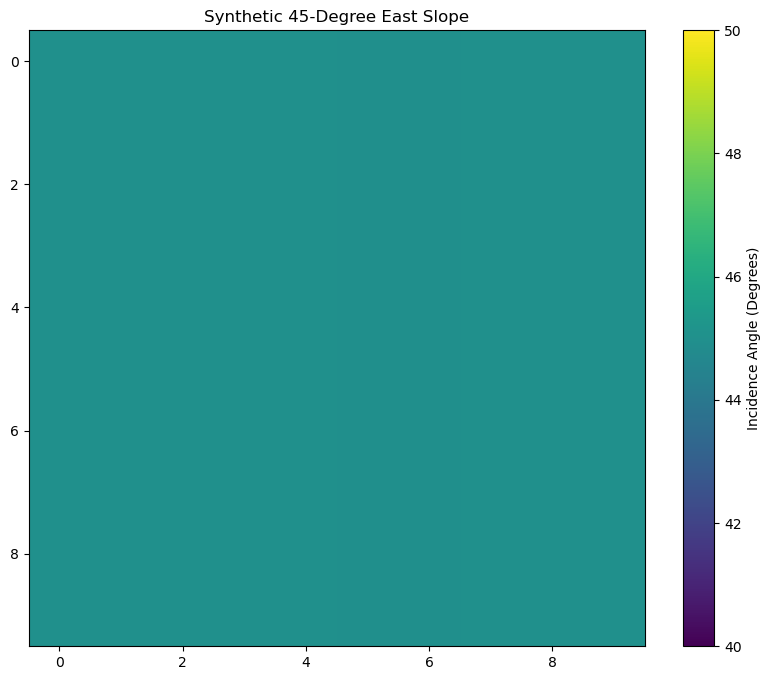

In [2]:
# Create a 10x10 synthetic DEM sloping East
# If we increase elevation by 5.556m for every 5.556m pixel, the slope is exactly 45 degrees.
pixel_size = 5.556
synthetic_dem = np.tile(np.arange(10), (10, 1)) * pixel_size

# Create synthetic look vectors (Sensor looking perfectly straight down)
lkv_x = np.full((10, 10), 0.0)
lkv_y = np.full((10, 10), 0.0)
lkv_z = np.full((10, 10), -1.0) # -1 means pointing straight down

# Calculate incidence angle
synthetic_inc = calc_inc_angle(synthetic_dem, lkv_x, lkv_y, lkv_z, pixel_size=pixel_size)

print(f"Expected Angle: 45.0 degrees")
print(f"Calculated Angle: {np.nanmean(synthetic_inc):.2f} degrees")

# Quick visual check (should be a uniform flat color)
plt.imshow(synthetic_inc, cmap='viridis', vmin=40, vmax=50)
plt.colorbar(label='Incidence Angle (Degrees)')
plt.title("Synthetic 45-Degree East Slope")
plt.show()

In [3]:
# --- 1. Set up Paths ---
geo_dir_05208 = Path("/bsuhome/julialober/scratch/coherence_data/uavsar_geoslcs/lowman/05208")
lkv_x_fp = geo_dir_05208 / "lowman_05208_01_BU_s1_2x8.lkv.x.tif"
lkv_y_fp = geo_dir_05208 / "lowman_05208_01_BU_s1_2x8.lkv.y.tif"
lkv_z_fp = geo_dir_05208 / "lowman_05208_01_BU_s1_2x8.lkv.z.tif"

# --- 2. Load Look Vectors (in EPSG:4326) ---
print("Loading LKV files...")
lkv_x_4326 = rioxarray.open_rasterio(lkv_x_fp, masked=True).squeeze()
lkv_y_4326 = rioxarray.open_rasterio(lkv_y_fp, masked=True).squeeze()
lkv_z_4326 = rioxarray.open_rasterio(lkv_z_fp, masked=True).squeeze()

# --- 3. Fetch the DEM using py3dep ---
# Extract bounding box from the LKV file to ensure perfect overlap
aoi_4326 = box(*lkv_x_4326.rio.bounds())
print("Fetching DEM via py3dep...")
dem_4326 = py3dep.get_dem(geometry=aoi_4326, resolution=30, crs="EPSG:4326")

# --- 4. Reproject to UTM Zone 11N (Meters) ---
utm_crs = "EPSG:32611" # Lowman, ID is in UTM Zone 11N
res_m = 5.556 # Standard UAVSAR pixel resolution in meters

print(f"Reprojecting arrays to {utm_crs}...")
lkv_x_utm = lkv_x_4326.rio.reproject(utm_crs, resolution=res_m)
lkv_y_utm = lkv_y_4326.rio.reproject(utm_crs, resolution=res_m)
lkv_z_utm = lkv_z_4326.rio.reproject(utm_crs, resolution=res_m)

# Use reproject_match to force the DEM to perfectly align with the new LKV grid
dem_utm = dem_4326.rio.reproject_match(lkv_x_utm)

# --- 5. Calculate True Incidence Angle ---
# We pass the raw numpy arrays (.values) directly into our fixed function!
print("Calculating incidence angle...")
inc_utm_arr = calc_inc_angle(
    dem=dem_utm.values,
    lkv_x=lkv_x_utm.values,
    lkv_y=lkv_y_utm.values,
    lkv_z=lkv_z_utm.values,
    pixel_size=res_m
)

# --- 6. Reproject Back to EPSG:4326 ---
print("Reprojecting results back to EPSG:4326...")
# First, wrap the numpy array back into an xarray object with the UTM spatial info
inc_utm_da = lkv_x_utm.copy(data=inc_utm_arr)

# Then, warp it back to 4326 so it perfectly matches the original grid
inc_4326_da = inc_utm_da.rio.reproject_match(lkv_x_4326)

# (Optional) Save the final product to disk
# out_tif = geo_dir_05208 / "lowman_05208_incidence_angle.tif"
# inc_4326_da.rio.to_raster(out_tif)
# print(f"Saved to: {out_tif}")

Loading LKV files...
Fetching DEM via py3dep...
Reprojecting arrays to EPSG:32611...
Calculating incidence angle...
Reprojecting results back to EPSG:4326...


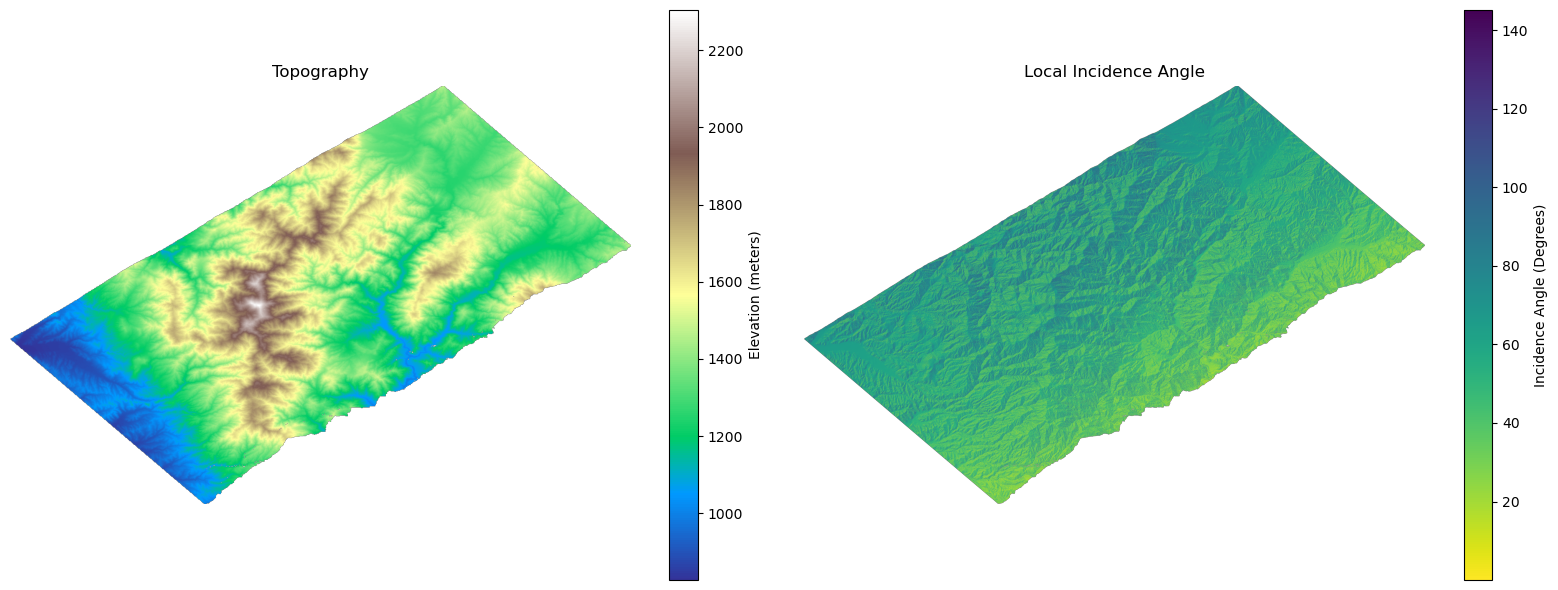

In [4]:
# --- 7. Plot the Results Side-by-Side ---

# Set a downsampling factor to speed up plotting (e.g., 10 means take every 10th pixel)
factor = 10

# 1. Trim and mask the DEM to perfectly match the incidence angle swath
# reproject_match perfectly aligns the grids, and .where applies the NaN mask from the radar data
dem_matched = dem_4326.rio.reproject_match(inc_4326_da)
dem_trimmed = dem_matched.where(inc_4326_da.notnull())

# 2. Downsample the arrays for lightning-fast plotting using NumPy slicing
dem_plot_data = dem_trimmed.squeeze().values[::factor, ::factor]
inc_plot_data = inc_4326_da.squeeze().values[::factor, ::factor]

# 3. Generate the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: The DEM (Elevation)
dem_plot = ax1.imshow(dem_plot_data, cmap='terrain')
ax1.set_title(f"Topography")
fig.colorbar(dem_plot, ax=ax1, label='Elevation (meters)')
ax1.axis('off') # Hides axis ticks for a cleaner map look

# Plot 2: The Calculated Incidence Angle
inc_plot = ax2.imshow(inc_4326_da.values, cmap='viridis_r')
ax2.set_title(f"Local Incidence Angle")
fig.colorbar(inc_plot, ax=ax2, label='Incidence Angle (Degrees)')
ax2.axis('off')

plt.tight_layout()
plt.show()